# 01 - Model Packaging Foundations (Zero to Hero)

This notebook starts from first principles and teaches **what model packaging means** in production ML.

## Definition
Model packaging is process of turning trained model into reusable software artifact with versioning, metadata, and stable interfaces.

## Theory
Raw training code alone is not enough for production. Teams need deterministic artifacts, dependency boundaries, and predictable API contracts.

## Motivation
Without packaging, deployment becomes manual and fragile. With packaging, one trained model can be reused by API, CLI, batch jobs, and tests.

## Real-World Example
Fraud model trained by one team can be versioned and consumed by:
- Realtime API for card authorizations
- Batch risk scoring pipeline
- Internal analyst notebook tools

## Best Practices
- Keep model artifacts immutable
- Attach checksums + metadata
- Track model versions in registry
- Separate training and serving concerns

## Common Mistakes
- Saving only one `.pkl` with no metadata
- No input validation layer
- No rollback strategy
- No reproducible dependency lock


In [1]:
from pathlib import Path
import os

CWD = Path.cwd()
ROOT = CWD if (CWD / "pyproject.toml").exists() else CWD.parent
os.chdir(ROOT)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/benchmarks").mkdir(parents=True, exist_ok=True)


## Lifecycle Theory and Visual Explanation

### Definition
Lifecycle means complete flow from raw data to production inference.

### Theory
Flow stages:
1. Raw Data
2. Training
3. Model Artifact
4. Packaging
5. Serving
6. Production

### Motivation
Each stage introduces risk. Packaging stage is control point where model becomes governed software.


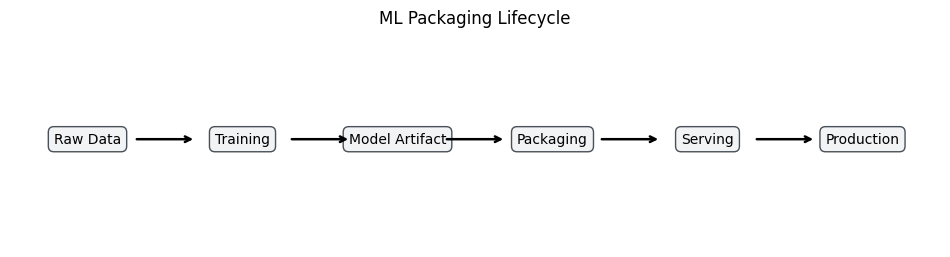

Saved: outputs/figures/notebook01_lifecycle.png


In [2]:
import matplotlib.pyplot as plt

steps = ["Raw Data", "Training", "Model Artifact", "Packaging", "Serving", "Production"]
x = list(range(len(steps)))

plt.figure(figsize=(12, 2.8))
for idx, label in enumerate(steps):
    plt.text(
        idx, 0.5, label, ha="center", va="center",
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "#f1f3f5", "edgecolor": "#495057"},
    )
for idx in range(len(steps) - 1):
    plt.annotate("", xy=(idx + 0.7, 0.5), xytext=(idx + 0.3, 0.5), arrowprops={"arrowstyle": "->", "lw": 1.8})
plt.xlim(-0.5, len(steps) - 0.5)
plt.ylim(0, 1)
plt.axis("off")
plt.title("ML Packaging Lifecycle")
out = Path("outputs/figures/notebook01_lifecycle.png")
plt.savefig(out, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")


## Packaging Architecture (Client -> API -> Wrapper -> Artifact -> Prediction)

### Theory
Wrapper layer decouples model file format from serving interface.

### Code Explanation
The code below draws reference architecture used in this project.


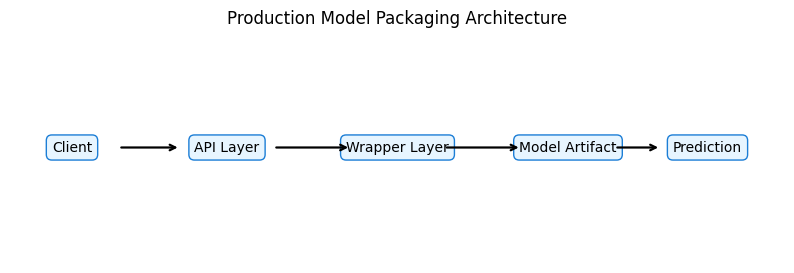

Saved: outputs/figures/notebook01_architecture.png


In [3]:
import matplotlib.pyplot as plt

blocks = ["Client", "API Layer", "Wrapper Layer", "Model Artifact", "Prediction"]
xs = [0.08, 0.28, 0.50, 0.72, 0.90]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
for label, x in zip(blocks, xs):
    ax.text(
        x, 0.5, label, ha="center", va="center",
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "#e7f5ff", "edgecolor": "#1c7ed6"},
        transform=ax.transAxes,
    )
for start, end in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(end - 0.06, 0.5), xytext=(start + 0.06, 0.5), arrowprops={"arrowstyle": "->", "lw": 1.6}, xycoords=ax.transAxes)
ax.set_title("Production Model Packaging Architecture")
out = Path("outputs/figures/notebook01_architecture.png")
fig.savefig(out, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")
